# Lecture 18: Projection — the Universal Readout

### One operation behind geometry, AI, and quantum measurement

`FRAMEWORK.md` argues that modern computation transforms **high-dimensional
vectors**, and that we only ever *observe* them through a **lower-dimensional
readout**. This lecture shows that the readout is, in all three domains, the
**same linear-algebra operation**: projecting a vector onto a direction (or
subspace) and reading off the component — the inner product $\langle b \mid x \rangle$.

- **Geometry:** a 3-D object's 2-D shadow is a projection.
- **AI:** a sentence's similarity to a concept is a projection of its embedding.
- **Quantum:** a measurement outcome's probability is a projection of the state.

Same matrix move, three meanings. Let's build it once and apply it three times.

## 0. The projector

For a **unit** vector $u$, the matrix $P = u u^\top$ projects any vector onto the
$u$ direction: $P x = (u \cdot x)\, u$. The scalar $u \cdot x$ is the **readout** —
how much of $x$ points along $u$. A projector is **idempotent** ($P^2 = P$):
projecting twice changes nothing, because you're already on the line.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)

def projector(u):
    u = np.asarray(u, float); u = u / np.linalg.norm(u)
    return np.outer(u, u)

u = [3.0, 4.0]
P = projector(u)
x = np.array([5.0, 0.0])
print('P x      =', P @ x, '  (x projected onto u)')
print('readout  =', (np.array(u)/np.linalg.norm(u)) @ x, '  (the scalar component along u)')
print('P P == P  (idempotent)?', np.allclose(P @ P, P))

P x      = [1.8 2.4]   (x projected onto u)
readout  = 3.0   (the scalar component along u)
P P == P  (idempotent)? True


## 1. Geometry: a shadow is a projection

A cube lives in 3-D. Its shadow on a wall is a projection onto a 2-D plane — we
drop the component along the viewing direction. We *observe* the 2-D shadow, but
the object is 3-D. (This is the handoff's slice/projection intuition, made
literal.)

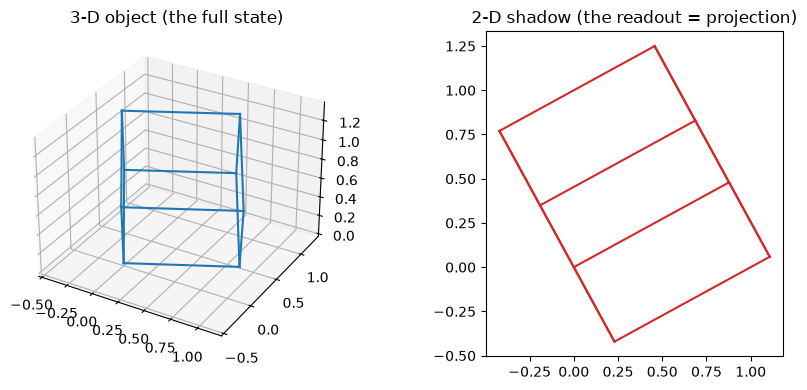

In [2]:
# Cube vertices and edges
pts = np.array([[x, y, z] for x in (0,1) for y in (0,1) for z in (0,1)], float)
edges = [(i, j) for i in range(8) for j in range(i+1, 8)
         if np.sum(np.abs(pts[i]-pts[j])) == 1]

# Rotate a little, then project onto the x-y plane (drop z = project out the z direction)
t = 0.5
Rz = np.array([[np.cos(t), -np.sin(t), 0],[np.sin(t), np.cos(t), 0],[0,0,1]])
Rx = np.array([[1,0,0],[0,np.cos(t),-np.sin(t)],[0,np.sin(t),np.cos(t)]])
R = Rz @ Rx
pts_r = pts @ R.T
shadow = pts_r[:, :2]                 # projection: keep x,y; drop z

fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
for i, j in edges:
    ax1.plot(*zip(pts_r[i], pts_r[j]), color='tab:blue')
ax1.set_title('3-D object (the full state)')
ax2 = fig.add_subplot(1, 2, 2)
for i, j in edges:
    ax2.plot(*zip(shadow[i], shadow[j]), color='tab:red')
ax2.set_aspect('equal'); ax2.set_title('2-D shadow (the readout = projection)')
plt.tight_layout(); plt.show()

## 2. AI: reading meaning is projecting onto a concept direction

In Lecture 12 a sentence became a 384-D unit vector. A **concept** is a
direction in that space. Projecting a sentence's embedding onto the concept
direction — the inner product — reads off *how much that sentence expresses the
concept*. The same $u \cdot x$ as above.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

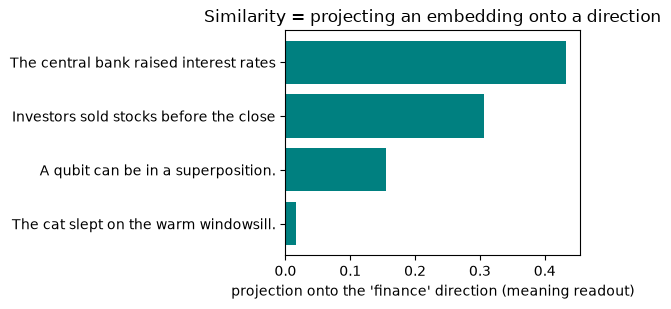

+0.433  The central bank raised interest rates.
+0.306  Investors sold stocks before the close.
+0.155  A qubit can be in a superposition.
+0.017  The cat slept on the warm windowsill.


In [3]:
from sentence_transformers import SentenceTransformer
emb = SentenceTransformer('all-MiniLM-L6-v2')

concept_examples = ['money, markets, and investing', 'finance and the economy']
u_concept = emb.encode(concept_examples, normalize_embeddings=True).mean(0)
u_concept /= np.linalg.norm(u_concept)            # the 'finance' direction

sentences = [
    'The central bank raised interest rates.',
    'Investors sold stocks before the close.',
    'A qubit can be in a superposition.',
    'The cat slept on the warm windowsill.',
]
V = emb.encode(sentences, normalize_embeddings=True)
readout = V @ u_concept                            # projection onto the concept

order = np.argsort(-readout)
plt.figure(figsize=(6, 3.2))
plt.barh([sentences[i][:38] for i in order][::-1], readout[order][::-1], color='teal')
plt.xlabel('projection onto the \'finance\' direction (meaning readout)')
plt.title('Similarity = projecting an embedding onto a direction')
plt.tight_layout(); plt.show()
for i in order:
    print(f'{readout[i]:+.3f}  {sentences[i]}')

## 3. Quantum: a measurement is a projection of the state

A qubit state $|\psi\rangle = \cos\theta\,|0\rangle + \sin\theta\,|1\rangle$ is a unit vector
(Lecture 5). Measuring in the $Z$ basis projects it onto $|0\rangle$ or $|1\rangle$; the
probability of outcome $0$ is the squared projection $|\langle 0|\psi\rangle|^2 = \cos^2\theta$.

Crucially, **which basis you measure in is which directions you project onto**.
Measuring in the $X$ basis projects onto $|+\rangle, |-\rangle$ instead — the
eigenvectors of Pauli-X (Lecture 16). Same state, different readout.

In [4]:
ket0 = np.array([1.0, 0.0]); ket1 = np.array([0.0, 1.0])
plus = (ket0 + ket1)/np.sqrt(2); minus = (ket0 - ket1)/np.sqrt(2)

theta = np.pi/5
psi = np.cos(theta)*ket0 + np.sin(theta)*ket1

def born_probs(state, basis):
    return np.array([ (b @ state)**2 for b in basis ])   # |<b|psi>|^2 = squared projection

pZ = born_probs(psi, [ket0, ket1])
pX = born_probs(psi, [plus, minus])
print(f'Z-basis: P(0)={pZ[0]:.3f}  P(1)={pZ[1]:.3f}   (= cos^2 t, sin^2 t)')
print(f'X-basis: P(+)={pX[0]:.3f}  P(-)={pX[1]:.3f}   (same state, different projection)')

# Simulate measurements: empirical frequency converges to the projected probability
rng = np.random.default_rng(0)
samples = rng.choice([0, 1], size=5000, p=pZ)
print(f'\n5000 Z-measurements: empirical P(0)={np.mean(samples==0):.3f}  vs theory {pZ[0]:.3f}')

Z-basis: P(0)=0.655  P(1)=0.345   (= cos^2 t, sin^2 t)
X-basis: P(+)=0.976  P(-)=0.024   (same state, different projection)

5000 Z-measurements: empirical P(0)=0.652  vs theory 0.655


## The synthesis

In every row the readout is the **same operation** — the inner product of the
state with a chosen direction (then, for quantum, squared):

| Domain | High-dimensional state | Readout (a projection) |
|--------|------------------------|------------------------|
| Geometry | a 3-D (or n-D) shape | its shadow: drop the viewing direction |
| AI | a 384-D embedding | $u \cdot x$ onto a concept direction = similarity |
| Quantum | a state vector in Hilbert space | $|\langle b|\psi\rangle|^2$ onto a basis = outcome probability |

This is the executable core of `FRAMEWORK.md`: **the object is high-dimensional;
what we observe is a projection.** Geometry, meaning, and measurement are three
readings of one linear-algebra move.

## Exercises

1. **Measurement as projection vs. constraint.** Build the projectors
   $P_0 = |0\rangle\langle0|$ and $P_1 = |1\rangle\langle1|$. Show $P_0 + P_1 = I$ and that
   $\langle\psi|P_0|\psi\rangle$ equals $P(0)$. Which view — projection or constraint — feels
   more natural?
2. **Subspace projection.** Project the embeddings onto a 2-D concept *plane*
   (two directions) instead of one, using $P = U U^\top$ with orthonormal columns.
3. **Rotate before projecting.** In the cube demo, change the rotation and watch
   the shadow change — the object is fixed; the readout depends on the basis.
4. **Connect to PCA (Lecture 16).** PCA projects onto the top eigenvectors of
   the covariance. Show that projecting embeddings onto the top-2 principal
   directions is the 'best' 2-D shadow in a precise (variance) sense.
5. **Connect to attention (Lecture 17).** Attention weights come from projecting
   each query onto every key. Re-read the score matrix as 'how much each token
   projects onto each other token'.